Simple imputation is a technique used to handle missing data in a dataset. It involves replacing missing values with a specific value, such as the mean, median, or mode of the non-missing values in the same column. This method allows us to maintain the integrity of the dataset while still utilizing all available data for analysis or modeling.

Mean/median imputation is a common approach for numerical data, where missing values are replaced with the mean or median of the non-missing values in the same column. This method is simple and effective when the data is normally distributed or has a symmetric distribution. However, it may not be suitable for skewed data or when there are outliers, as it can distort the distribution of the data.  

when to use mean/median imputation:
- When the data is normally distributed or has a symmetric distribution.
- When there are no significant outliers in the data.
- When the percentage of missing values is relatively low (e.g., less than 5%).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer


In [4]:
df=pd.read_csv('./titanic_toy.csv')

In [8]:
df.sample(5)

,Age,Fare,Family,Survived
163,17.0,8.6625,0,0
70,32.0,10.5000,0,0
739,NaN,7.8958,0,0
477,29.0,7.0458,1,0
832,NaN,7.2292,0,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [10]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [11]:
X=df.drop('Survived',axis=1)
y=df['Survived']

In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [15]:
X_train.isnull().mean()

Age       0.207865
Fare      0.050562
Family    0.000000
dtype: float64

In [16]:
mean_age=X_train['Age'].mean()
median_age=X_train['Age'].median()

In [17]:
mean_fare=X_train['Fare'].mean()
median_fare=X_train['Fare'].median()

In [18]:
X_train['Age_median']=X_train['Age'].fillna(median_age)
X_train['Age_mean']=X_train['Age'].fillna(mean_age)
X_train['Fare_median']=X_train['Fare'].fillna(median_fare)
X_train['Fare_mean']=X_train['Fare'].fillna(mean_fare)

In [20]:
X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
472,33.0,27.75,3,33.0,33.0,27.7500,27.750000
338,45.0,8.05,0,45.0,45.0,8.0500,8.050000
890,32.0,7.75,0,32.0,32.0,7.7500,7.750000
162,26.0,NaN,0,26.0,26.0,14.4583,32.617597
829,62.0,80.00,0,62.0,62.0,80.0000,80.000000


In [23]:
print('Orginal Age variable variance:',X_train['Age'].var())
print('Age variance after median imputation',X_train['Age_median'].var())
print('Age variance after mean imputation',X_train['Age_mean'].var())
print('Orginal Fare variable variance:',X_train['Fare'].var())
print('Fare variance after median imputation',X_train['Fare_median'].var())
print('Fare variance after mean imputation',X_train['Fare_mean'].var())

Orginal Age variable variance: 204.34951339046142
Age variance after median imputation 161.98956633460548
Age variance after mean imputation 161.81262452718676
Orginal Fare variable variance: 2448.1979137063163
Fare variance after median imputation 2340.09102197536
Fare variance after mean imputation 2324.2385256705534


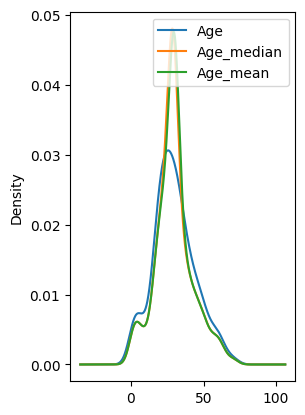

In [24]:
fig=plt.figure()
ax=fig.add_subplot(1,2,1)
X_train['Age'].plot(kind='kde',ax=ax)
X_train['Age_median'].plot(kind='kde',ax=ax)
X_train['Age_mean'].plot(kind='kde',ax=ax)
lines,labels=ax.get_legend_handles_labels()
ax.legend(['Age','Age_median','Age_mean'])

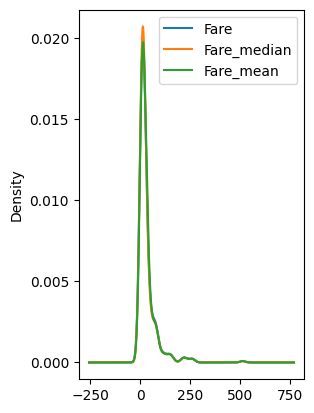

In [25]:
fig=plt.figure()
ax=fig.add_subplot(1,2,1)
X_train['Fare'].plot(kind='kde',ax=ax)
X_train['Fare_median'].plot(kind='kde',ax=ax)
X_train['Fare_mean'].plot(kind='kde',ax=ax)
lines,labels=ax.get_legend_handles_labels()
ax.legend(['Fare','Fare_median','Fare_mean'])

In [26]:
X_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,64.858859,66.665205
Fare,70.719262,2448.197914,17.258917,57.957599,55.603719,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.112563,-5.146106,16.476305,16.385048
Age_median,204.349513,57.957599,-5.112563,161.989566,161.812625,53.553455,55.023037
Age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,51.358000,52.788341
Fare_median,64.858859,2448.197914,16.476305,53.553455,51.358000,2340.091022,2324.238526
Fare_mean,66.665205,2448.197914,16.385048,55.023037,52.788341,2324.238526,2324.238526


<Axes: >

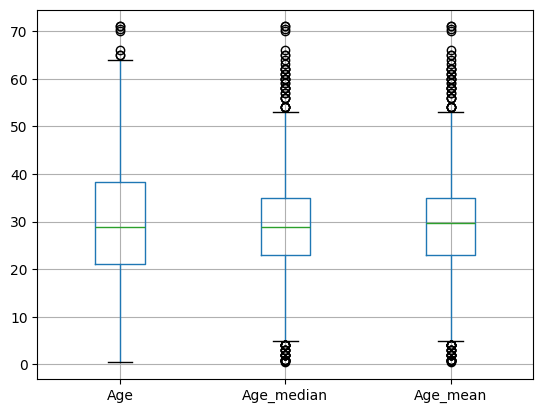

In [27]:
X_train[['Age','Age_median','Age_mean']].boxplot()

<Axes: >

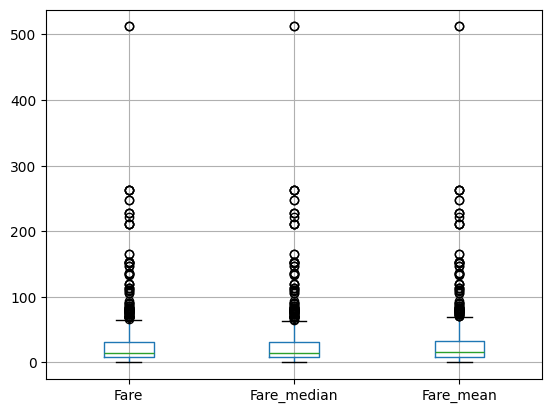

In [28]:
X_train[['Fare','Fare_median','Fare_mean']].boxplot()

Using  sklearn's SimpleImputer for mean/median imputation:


In [34]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [35]:
imputer1=SimpleImputer(strategy='median')
imputer2=SimpleImputer(strategy='mean')

In [36]:
trf=ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [37]:
trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

In [38]:
trf.named_transformers_['imputer1'].statistics_

array([28.])

In [39]:
X_train=trf.transform(X_train)
X_test=trf.transform(X_test)

Arbitrary value imputation is a technique used to handle missing data by replacing missing values with a specific arbitrary value. This method can be useful when the missing values have a specific meaning or when we want to create a new category for the missing data. For example, if we have a categorical variable with missing values, we can replace them with a new category called "Unknown" or "Missing". 

When to use arbitrary value imputation:
- When the missing values have a specific meaning or when we want to create a new category for the missing data.
- When the percentage of missing values is relatively high (e.g., more than 5%).


In [42]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [43]:
X_train['Age_99']=X_train['Age'].fillna(99)
X_train['Age_minus1']=X_train['Age'].fillna(-1)
X_train['Fare_999']=X_train['Fare'].fillna(999)
X_train['Fare_minus1']=X_train['Fare'].fillna(-1)